In [1]:
#AI-Powered Intelligent News Search System Using Sentence Transformers and Vector Databases
!pip install -q sentence-transformers
!pip install -q faiss-cpu
!pip install -q chromadb
!pip install -q matplotlib
!pip install -q pandas

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 18.5/18.5 MB 95.4 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 52.0/52.0 kB 3.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 23.3/23.3 MB 89.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 278.2/278.2 kB 24.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 4.6/4.6 MB 122.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 19.2/19.2 MB 85.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 72.5/72.5 kB 7.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 137.2/137.2 kB 8.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 60.0/60.0 kB 5.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 204.6/204.6 kB 19.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 71.6/71.6 kB 6.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 61.7/61.7 kB 6.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 60.6/60

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import time
import re

from sentence_transformers import SentenceTransformer

import faiss
import chromadb

In [3]:
from google.colab import files

uploaded = files.upload()

Saving News_Category_Dataset_v3.json to News_Category_Dataset_v3.json


In [4]:
df = pd.read_json(
    "News_Category_Dataset_v3.json",
    lines=True
)

df.head()

,link,headline,category,short_description,authors,date
0,https://www.huffpost.com/entry/covid-boosters-...,Over 4 Million Americans Roll Up Sleeves For O...,U.S. NEWS,Health experts said it is too early to predict...,"Carla K. Johnson, AP",2022-09-23
1,https://www.huffpost.com/entry/american-airlin...,"American Airlines Flyer Charged, Banned For Li...",U.S. NEWS,He was subdued by passengers and crew when he ...,Mary Papenfuss,2022-09-23
2,https://www.huffpost.com/entry/funniest-tweets...,23 Of The Funniest Tweets About Cats And Dogs ...,COMEDY,"""Until you have a dog you don't understand wha...",Elyse Wanshel,2022-09-23
3,https://www.huffpost.com/entry/funniest-parent...,The Funniest Tweets From Parents This Week (Se...,PARENTING,"""Accidentally put grown-up toothpaste on my to...",Caroline Bologna,2022-09-23
4,https://www.huffpost.com/entry/amy-cooper-lose...,Woman Who Called Cops On Black Bird-Watcher Lo...,U.S. NEWS,Amy Cooper accused investment firm Franklin Te...,Nina Golgowski,2022-09-22


In [5]:
print("Dataset Shape:")
print(df.shape)

print("\nColumns:")
print(df.columns)

print("\nData Types:")
print(df.dtypes)

print("\nMissing Values:")
print(df.isnull().sum())

print("\nDuplicate Rows:")
print(df.duplicated().sum())

Dataset Shape:
(209527, 6)

Columns:
Index(['link', 'headline', 'category', 'short_description', 'authors', 'date'], dtype='object')

Data Types:
link                         object
headline                     object
category                     object
short_description            object
authors                      object
date                 datetime64[ns]
dtype: object

Missing Values:
link                 0
headline             0
category             0
short_description    0
authors              0
date                 0
dtype: int64

Duplicate Rows:
13


In [6]:
df.sample(5)

,link,headline,category,short_description,authors,date
201659,https://www.huffingtonpost.comhttp://earth911....,Earth Day 2012 Environmental Issues: Recycling...,ENVIRONMENT,From government regulations and recycling serv...,,2012-04-22
180410,https://www.huffingtonpost.com/entry/sleep-tra...,"Maybe Grandma Was Right, You Can 'Spoil' a Baby!",PARENTING,t's fun to read antiquated parenting advice an...,"Kim Siegal, Contributor\nblogger, mamamzungu.com",2012-12-07
70583,https://www.huffingtonpost.com/entry/chicago-s...,Chicago Senator Wants To Waive $150 GED Fees F...,IMPACT,"“That’s not too much to ask.""",Eleanor Goldberg,2016-04-08
184989,https://www.huffingtonpost.com/entry/chocolate...,Chocolate Croissants Are Crying On The Inside ...,FOOD & DRINK,How did we miss the signs?!,,2012-10-18
202338,https://www.huffingtonpost.com/entry/aging-hea...,Two Ways To Live Longer And Healthier,WELLNESS,"Young or old, you can promote lasting health b...","Elaine Gavalas, Contributor\nAuthor; Natural H...",2012-04-14


In [7]:
news_df = df.copy()
news_df.head()

,link,headline,category,short_description,authors,date
0,https://www.huffpost.com/entry/covid-boosters-...,Over 4 Million Americans Roll Up Sleeves For O...,U.S. NEWS,Health experts said it is too early to predict...,"Carla K. Johnson, AP",2022-09-23
1,https://www.huffpost.com/entry/american-airlin...,"American Airlines Flyer Charged, Banned For Li...",U.S. NEWS,He was subdued by passengers and crew when he ...,Mary Papenfuss,2022-09-23
2,https://www.huffpost.com/entry/funniest-tweets...,23 Of The Funniest Tweets About Cats And Dogs ...,COMEDY,"""Until you have a dog you don't understand wha...",Elyse Wanshel,2022-09-23
3,https://www.huffpost.com/entry/funniest-parent...,The Funniest Tweets From Parents This Week (Se...,PARENTING,"""Accidentally put grown-up toothpaste on my to...",Caroline Bologna,2022-09-23
4,https://www.huffpost.com/entry/amy-cooper-lose...,Woman Who Called Cops On Black Bird-Watcher Lo...,U.S. NEWS,Amy Cooper accused investment firm Franklin Te...,Nina Golgowski,2022-09-22


In [8]:
print("Before Removing Duplicates:", news_df.shape)

news_df = news_df.drop_duplicates()

print("After Removing Duplicates:", news_df.shape)

Before Removing Duplicates: (209527, 6)
After Removing Duplicates: (209514, 6)


In [9]:
def clean_text(text):

    text = str(text)

    text = text.lower()

    text = text.strip()

    text = text.replace("\n", " ")

    text = re.sub(r"http\S+", "", text)

    text = re.sub(r"[^a-zA-Z0-9 ]", "", text)

    text = re.sub(r"\s+", " ", text)

    return text

In [10]:
news_df["headline"] = news_df["headline"].apply(clean_text)
news_df["short_description"] = news_df["short_description"].apply(clean_text)

In [11]:
news_df["search_text"] = (
    news_df["headline"] +
    " " +
    news_df["short_description"]
)

In [12]:
news_df[["headline", "short_description", "search_text"]].head()

,headline,short_description,search_text
0,over 4 million americans roll up sleeves for o...,health experts said it is too early to predict...,over 4 million americans roll up sleeves for o...
1,american airlines flyer charged banned for lif...,he was subdued by passengers and crew when he ...,american airlines flyer charged banned for lif...
2,23 of the funniest tweets about cats and dogs ...,until you have a dog you dont understand what ...,23 of the funniest tweets about cats and dogs ...
3,the funniest tweets from parents this week sep...,accidentally put grownup toothpaste on my todd...,the funniest tweets from parents this week sep...
4,woman who called cops on black birdwatcher los...,amy cooper accused investment firm franklin te...,woman who called cops on black birdwatcher los...


In [13]:
empty_rows = (news_df["search_text"].str.strip() == "").sum()
print("Empty Search Text:", empty_rows)

Empty Search Text: 6


In [14]:
news_df.to_csv("cleaned_news_dataset.csv", index=False)
print("Cleaned dataset saved successfully.")

Cleaned dataset saved successfully.


In [15]:
print("Total Articles :", len(news_df))
print("Total Categories :", news_df["category"].nunique())
print("\nCategories:\n")
print(news_df["category"].unique())

Total Articles : 209514
Total Categories : 42

Categories:

['U.S. NEWS' 'COMEDY' 'PARENTING' 'WORLD NEWS' 'CULTURE & ARTS' 'TECH'
 'SPORTS' 'ENTERTAINMENT' 'POLITICS' 'WEIRD NEWS' 'ENVIRONMENT'
 'EDUCATION' 'CRIME' 'SCIENCE' 'WELLNESS' 'BUSINESS' 'STYLE & BEAUTY'
 'FOOD & DRINK' 'MEDIA' 'QUEER VOICES' 'HOME & LIVING' 'WOMEN'
 'BLACK VOICES' 'TRAVEL' 'MONEY' 'RELIGION' 'LATINO VOICES' 'IMPACT'
 'WEDDINGS' 'COLLEGE' 'PARENTS' 'ARTS & CULTURE' 'STYLE' 'GREEN' 'TASTE'
 'HEALTHY LIVING' 'THE WORLDPOST' 'GOOD NEWS' 'WORLDPOST' 'FIFTY' 'ARTS'
 'DIVORCE']


In [16]:
category_count = news_df["category"].value_counts()
category_count

,count
category,
POLITICS,35601
WELLNESS,17942
ENTERTAINMENT,17362
TRAVEL,9900
STYLE & BEAUTY,9811
PARENTING,8791
HEALTHY LIVING,6694
QUEER VOICES,6347
FOOD & DRINK,6340


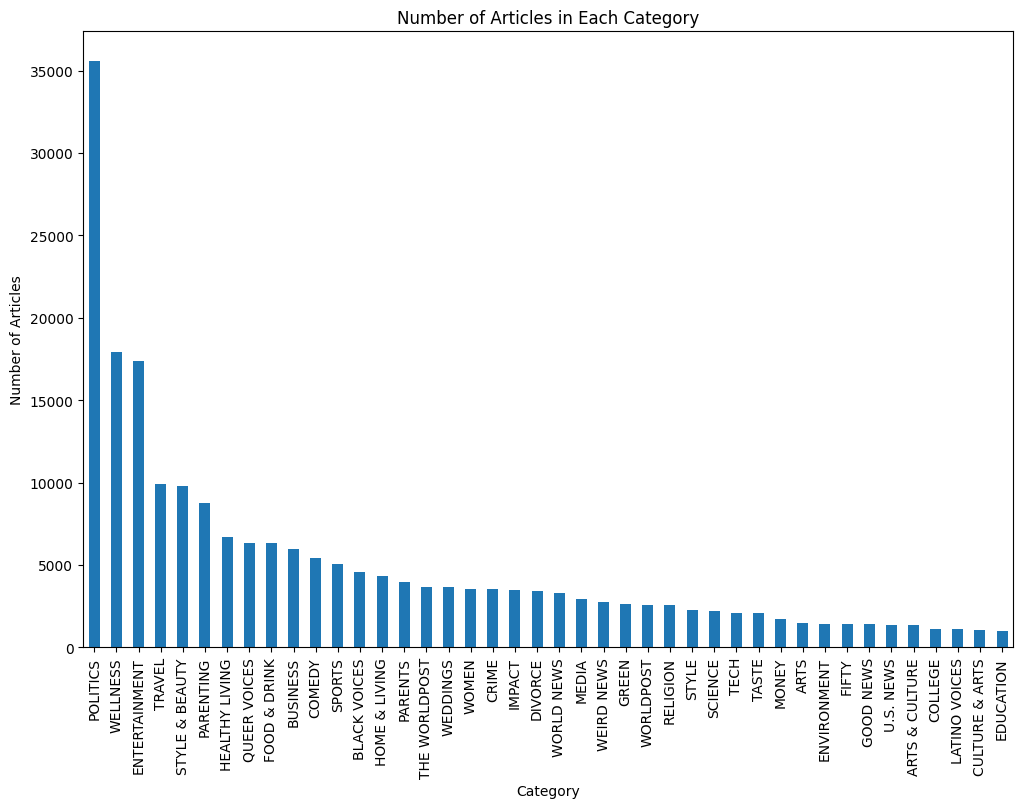

In [17]:
plt.figure(figsize=(12,8))
category_count.plot(kind="bar")
plt.title("Number of Articles in Each Category")
plt.xlabel("Category")
plt.ylabel("Number of Articles")
plt.xticks(rotation=90)
plt.show()

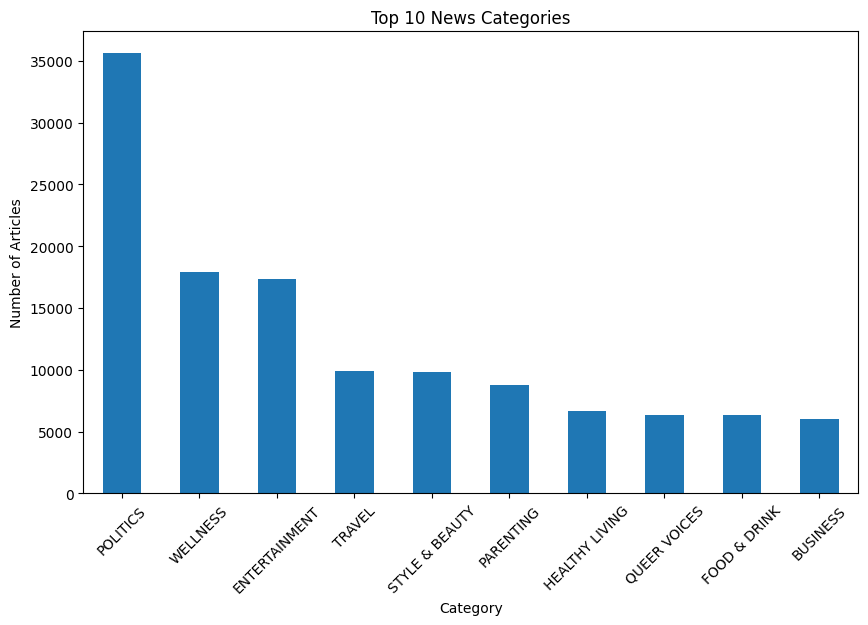

In [18]:
top10 = category_count.head(10)
plt.figure(figsize=(10,6))
top10.plot(kind="bar")
plt.title("Top 10 News Categories")
plt.xlabel("Category")
plt.ylabel("Number of Articles")
plt.xticks(rotation=45)
plt.show()

In [19]:
news_df["article_length"] = news_df["search_text"].apply(len)
news_df["article_length"].describe()

,article_length
count,209514.000000
mean,168.411314
std,76.387580
min,1.000000
25%,119.000000
50%,166.000000
75%,202.000000
max,1420.000000


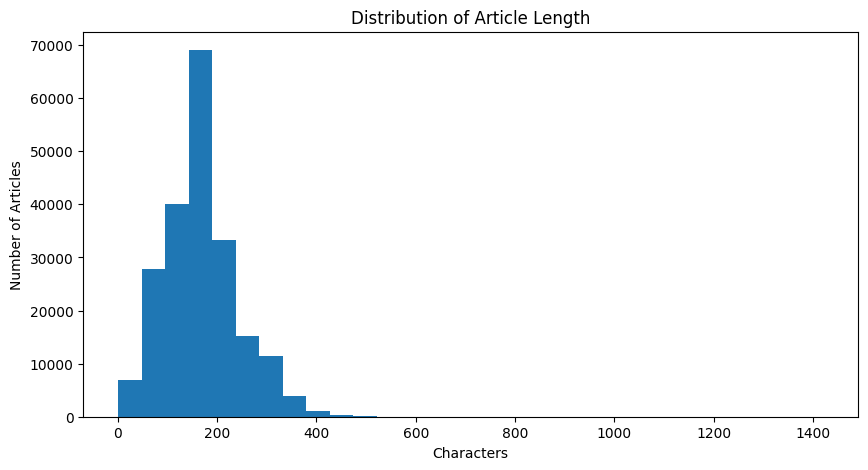

In [20]:
plt.figure(figsize=(10,5))
plt.hist(news_df["article_length"], bins=30)
plt.title("Distribution of Article Length")
plt.xlabel("Characters")
plt.ylabel("Number of Articles")
plt.show()

In [21]:
print("Longest Article Length:")
print(news_df["article_length"].max())
print("\nShortest Article Length:")
print(news_df["article_length"].min())
print("\nAverage Article Length:")
print(round(news_df["article_length"].mean(),2))

Longest Article Length:
1420

Shortest Article Length:
1

Average Article Length:
168.41


In [22]:
embedding_df = news_df.sample(
    n=30000,
    random_state=42
).reset_index(drop=True)
print(embedding_df.shape)

(30000, 8)


In [23]:
model = SentenceTransformer("all-MiniLM-L6-v2")

modules.json:   0%|          | 0.00/349 [00:00<?, ?B/s]

config_sentence_transformers.json:   0%|          | 0.00/116 [00:00<?, ?B/s]

README.md:   0%|          | 0.00/10.5k [00:00<?, ?B/s]

sentence_bert_config.json:   0%|          | 0.00/53.0 [00:00<?, ?B/s]

config.json:   0%|          | 0.00/612 [00:00<?, ?B/s]

...

tokenizer_config.json:   0%|          | 0.00/350 [00:00<?, ?B/s]

vocab.txt:   0%|          | 0.00/232k [00:00<?, ?B/s]

tokenizer.json:   0%|          | 0.00/466k [00:00<?, ?B/s]

special_tokens_map.json:   0%|          | 0.00/112 [00:00<?, ?B/s]

config.json:   0%|          | 0.00/190 [00:00<?, ?B/s]

In [24]:
start_time = time.time()

In [25]:
embeddings = model.encode(
    embedding_df["search_text"].tolist(),
    batch_size=64,
    show_progress_bar=True,
    convert_to_numpy=True
)

Batches:   0%|          | 0/469 [00:00<?, ?it/s]

In [26]:
end_time = time.time()
embedding_time = end_time - start_time
print(f"Embedding Generation Time: {embedding_time:.2f} seconds")

Embedding Generation Time: 99.31 seconds


In [27]:
print("Embedding Shape:", embeddings.shape)

Embedding Shape: (30000, 384)


In [28]:
import numpy as np
np.save("news_embeddings.npy", embeddings)
print("Embeddings saved successfully.")

Embeddings saved successfully.


In [29]:
loaded_embeddings = np.load("news_embeddings.npy")
print(loaded_embeddings.shape)

(30000, 384)


In [30]:
embedding_dimension = embeddings.shape[1]
print("Embedding Dimension:", embedding_dimension)

Embedding Dimension: 384


In [31]:
index = faiss.IndexFlatL2(embedding_dimension)
print(index)

<faiss.swigfaiss.IndexFlatL2; proxy of <Swig Object of type 'faiss::IndexFlatL2 *' at 0x7ea91ba46cb0> >


In [32]:
start_time = time.time()
index.add(embeddings)
end_time = time.time()
faiss_index_time = end_time - start_time
print(f"FAISS Indexing Time: {faiss_index_time:.4f} seconds")

FAISS Indexing Time: 0.0341 seconds


In [33]:
print("Total vectors stored:", index.ntotal)

Total vectors stored: 30000


In [34]:
faiss.write_index(index, "news_faiss.index")
print("FAISS index saved successfully.")

FAISS index saved successfully.


In [35]:
loaded_index = faiss.read_index("news_faiss.index")
print("Loaded vectors:", loaded_index.ntotal)

Loaded vectors: 30000


In [36]:
query = "Artificial Intelligence in healthcare"

In [37]:
query_embedding = model.encode(
    [query],
    convert_to_numpy=True
)

In [38]:
start_time = time.time()
distances, indices = loaded_index.search(query_embedding, 5)
end_time = time.time()
faiss_query_time = end_time - start_time
print(f"Query Time: {faiss_query_time:.6f} seconds")

Query Time: 0.005968 seconds


In [39]:
results = embedding_df.iloc[indices[0]][
    ["headline", "category", "short_description"]
].copy()
results["Distance"] = distances[0]
results

,headline,category,short_description,Distance
9367,this groundbreaking algorithm can spot sepsis ...,HEALTHY LIVING,five ways artificial intelligence can improve ...,0.737072
1148,er may reveal basic problems in hospitals,IMPACT,simple common sense coupled with organized thi...,1.063921
6285,innovating the business of healthcare,WELLNESS,although some progressive healthcare providers...,1.116611
15916,health care waste is technology the answer or ...,WELLNESS,mobile technology telehealth automation and da...,1.129905
12888,my winter as a hospital intern how nonmedical ...,WELLNESS,my first day at the hospital largely consisted...,1.183851


In [40]:
for rank, idx in enumerate(indices[0], start=1):
    article = embedding_df.iloc[idx]
    print("=" * 80)
    print(f"Rank : {rank}")
    print(f"Category : {article['category']}")
    print(f"Headline : {article['headline']}")
    print(f"Description : {article['short_description']}")
    print(f"Distance : {distances[0][rank-1]:.4f}")

Rank : 1
Category : HEALTHY LIVING
Headline : this groundbreaking algorithm can spot sepsis before doctors
Description : five ways artificial intelligence can improve our lives
Distance : 0.7371
Rank : 2
Category : IMPACT
Headline : er may reveal basic problems in hospitals
Description : simple common sense coupled with organized thinking ought to be able to produce better medical benefits and patient care at substantially lower costs
Distance : 1.0639
Rank : 3
Category : WELLNESS
Headline : innovating the business of healthcare
Description : although some progressive healthcare providers have begun to transition to digitization enabling faster and more complete access to patient data we still have a long way to go toward achieving seamless process and business innovation in healthcare
Distance : 1.1166
Rank : 4
Category : WELLNESS
Headline : health care waste is technology the answer or part of the problem
Description : mobile technology telehealth automation and data analytics what d

In [41]:
similarity_scores = 1 / (1 + distances[0])
results = embedding_df.iloc[indices[0]][
    ["headline", "category", "short_description"]
].copy()
results["Similarity Score"] = similarity_scores
results

,headline,category,short_description,Similarity Score
9367,this groundbreaking algorithm can spot sepsis ...,HEALTHY LIVING,five ways artificial intelligence can improve ...,0.575681
1148,er may reveal basic problems in hospitals,IMPACT,simple common sense coupled with organized thi...,0.484515
6285,innovating the business of healthcare,WELLNESS,although some progressive healthcare providers...,0.472453
15916,health care waste is technology the answer or ...,WELLNESS,mobile technology telehealth automation and da...,0.469504
12888,my winter as a hospital intern how nonmedical ...,WELLNESS,my first day at the hospital largely consisted...,0.457907


In [42]:
queries = [
    "Artificial Intelligence",
    "Climate Change",
    "Stock Market",
    "Olympics",
    "Healthcare"
]
for query in queries:
    print("\n" + "="*100)
    print("Query:", query)
    query_embedding = model.encode([query], convert_to_numpy=True)
    distances, indices = loaded_index.search(query_embedding, 3)
    for i, idx in enumerate(indices[0]):
        print(f"\nRank {i+1}")
        print("Category :", embedding_df.iloc[idx]["category"])
        print("Headline :", embedding_df.iloc[idx]["headline"])


Query: Artificial Intelligence

Rank 1
Category : TECH
Headline : toyota makes major investment in artificial intelligence

Rank 2
Category : HEALTHY LIVING
Headline : this groundbreaking algorithm can spot sepsis before doctors

Rank 3
Category : TECH
Headline : ai day will replace christmas as the most important holiday in less than 25 years

Query: Climate Change

Rank 1
Category : GREEN
Headline : the drought of climate change support

Rank 2
Category : IMPACT
Headline : the earth league a call for sciencebased action

Rank 3
Category : GREEN
Headline : an interview with sara terry on effectively documenting climate change

Query: Stock Market

Rank 1
Category : COMEDY
Headline : future stock

Rank 2
Category : POLITICS
Headline : the stock market is up under trump clinton voters dont believe it

Rank 3
Category : MONEY
Headline : is the stock market going to kill you

Query: Olympics

Rank 1
Category : COMEDY
Headline : defense of london olympics

Rank 2
Category : HEALTHY LIVING

In [43]:
import chromadb
client = chromadb.Client()
print("ChromaDB Client Created Successfully")

ChromaDB Client Created Successfully


In [44]:
collection = client.create_collection(
    name="news_articles"
)
print("Collection Created Successfully")

Collection Created Successfully


In [45]:
print("Total Articles:", len(embedding_df))

Total Articles: 30000


In [46]:
ids = [str(i) for i in range(len(embedding_df))]

In [47]:
metadata = []
for _, row in embedding_df.iterrows():
    metadata.append({
        "headline": row["headline"],
        "category": row["category"],
        "description": row["short_description"]
    })

In [48]:
start_time = time.time()

In [50]:
batch_size = collection._client.get_max_batch_size()
print(batch_size)

5461


In [51]:
batch_size = collection._client.get_max_batch_size()
start_time = time.time()
for i in range(0, len(embedding_df), batch_size):
    collection.add(
        ids=ids[i:i+batch_size],
        embeddings=embeddings[i:i+batch_size].tolist(),
        metadatas=metadata[i:i+batch_size],
        documents=embedding_df["search_text"].tolist()[i:i+batch_size]
    )
end_time = time.time()
chroma_index_time = end_time - start_time
print(f"ChromaDB Indexing Time: {chroma_index_time:.2f} seconds")

ChromaDB Indexing Time: 30.70 seconds


In [52]:
end_time = time.time()
chroma_index_time = end_time - start_time
print(f"ChromaDB Indexing Time: {chroma_index_time:.2f} seconds")

ChromaDB Indexing Time: 58.16 seconds


In [53]:
print("Total Documents Stored:")
print(collection.count())

Total Documents Stored:
30000


In [54]:
query = "Artificial Intelligence in healthcare"

In [55]:
query_embedding = model.encode(
    query,
    convert_to_numpy=True
)

In [56]:
start_time = time.time()

results = collection.query(

    query_embeddings=[query_embedding.tolist()],

    n_results=5
)
end_time = time.time()
chroma_query_time = end_time - start_time
print(f"Query Time: {chroma_query_time:.6f} seconds")

Query Time: 0.007858 seconds


In [57]:
for i in range(5):
    print("="*80)
    print("Rank :", i+1)
    print("Headline :",
          results["metadatas"][0][i]["headline"])
    print("Category :",
          results["metadatas"][0][i]["category"])
    print("Description :",
          results["metadatas"][0][i]["description"])
    print("Distance :",
          round(results["distances"][0][i],4))

Rank : 1
Headline : this groundbreaking algorithm can spot sepsis before doctors
Category : HEALTHY LIVING
Description : five ways artificial intelligence can improve our lives
Distance : 0.7371
Rank : 2
Headline : er may reveal basic problems in hospitals
Category : IMPACT
Description : simple common sense coupled with organized thinking ought to be able to produce better medical benefits and patient care at substantially lower costs
Distance : 1.0639
Rank : 3
Headline : innovating the business of healthcare
Category : WELLNESS
Description : although some progressive healthcare providers have begun to transition to digitization enabling faster and more complete access to patient data we still have a long way to go toward achieving seamless process and business innovation in healthcare
Distance : 1.1166
Rank : 4
Headline : health care waste is technology the answer or part of the problem
Category : WELLNESS
Description : mobile technology telehealth automation and data analytics what d

In [58]:
print("="*80)
for i in range(5):
    similarity = 1 / (1 + results["distances"][0][i])
    print(f"Rank {i+1}")
    print("Headline:",
          results["metadatas"][0][i]["headline"])
    print("Similarity Score:",
          round(similarity,4))
    print()

Rank 1
Headline: this groundbreaking algorithm can spot sepsis before doctors
Similarity Score: 0.5757

Rank 2
Headline: er may reveal basic problems in hospitals
Similarity Score: 0.4845

Rank 3
Headline: innovating the business of healthcare
Similarity Score: 0.4725

Rank 4
Headline: health care waste is technology the answer or part of the problem
Similarity Score: 0.4695

Rank 5
Headline: my winter as a hospital intern how nonmedical professionals will change healthcare
Similarity Score: 0.4579



In [59]:
print("FAISS Indexing Time :", round(faiss_index_time, 4), "seconds")
print("ChromaDB Indexing Time :", round(chroma_index_time, 4), "seconds")

FAISS Indexing Time : 0.0341 seconds
ChromaDB Indexing Time : 58.1552 seconds


In [60]:
print("FAISS Query Time :", round(faiss_query_time, 6), "seconds")
print("ChromaDB Query Time :", round(chroma_query_time, 6), "seconds")

FAISS Query Time : 0.005968 seconds
ChromaDB Query Time : 0.007858 seconds


In [61]:
comparison = pd.DataFrame({

    "Feature":[
        "Indexing Time",
        "Query Time",
        "Metadata Support",
        "Storage",
        "Search Speed",
        "Ease of Use"
    ],

    "FAISS":[
        round(faiss_index_time,4),
        round(faiss_query_time,6),
        "Limited",
        "Vector Only",
        "Very Fast",
        "Easy"
    ],

    "ChromaDB":[
        round(chroma_index_time,4),
        round(chroma_query_time,6),
        "Excellent",
        "Vector + Metadata",
        "Fast",
        "Easy"
    ]
})
comparison

,Feature,FAISS,ChromaDB
0,Indexing Time,0.0341,58.1552
1,Query Time,0.005968,0.007858
2,Metadata Support,Limited,Excellent
3,Storage,Vector Only,Vector + Metadata
4,Search Speed,Very Fast,Fast
5,Ease of Use,Easy,Easy


In [62]:
comparison.to_csv("vector_database_comparison.csv", index=False)
print("Comparison table saved successfully.")

Comparison table saved successfully.


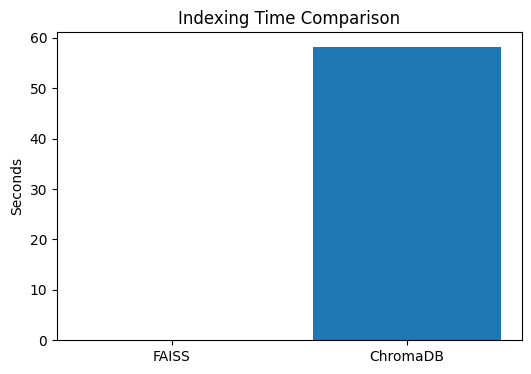

In [63]:
plt.figure(figsize=(6,4))
plt.bar(
    ["FAISS","ChromaDB"],
    [faiss_index_time, chroma_index_time]
)
plt.title("Indexing Time Comparison")
plt.ylabel("Seconds")
plt.show()

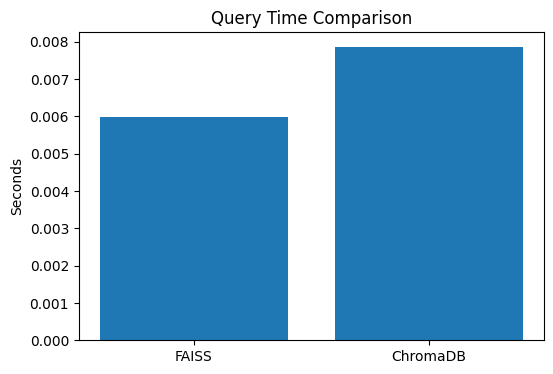

In [64]:
plt.figure(figsize=(6,4))
plt.bar(
    ["FAISS","ChromaDB"],
    [faiss_query_time, chroma_query_time]
)
plt.title("Query Time Comparison")
plt.ylabel("Seconds")
plt.show()

In [65]:
def confidence(score):
    if score >= 0.80:
        return "High"
    elif score >= 0.60:
        return "Medium"
    else:
        return "Low"

In [66]:
for i in range(5):
    similarity = 1/(1+results["distances"][0][i])
    print("="*70)
    print("Rank :", i+1)
    print("Headline :", results["metadatas"][0][i]["headline"])
    print("Similarity :", round(similarity,4))
    print("Confidence :", confidence(similarity))

Rank : 1
Headline : this groundbreaking algorithm can spot sepsis before doctors
Similarity : 0.5757
Confidence : Low
Rank : 2
Headline : er may reveal basic problems in hospitals
Similarity : 0.4845
Confidence : Low
Rank : 3
Headline : innovating the business of healthcare
Similarity : 0.4725
Confidence : Low
Rank : 4
Headline : health care waste is technology the answer or part of the problem
Similarity : 0.4695
Confidence : Low
Rank : 5
Headline : my winter as a hospital intern how nonmedical professionals will change healthcare
Similarity : 0.4579
Confidence : Low


In [67]:
search_history = []
queries = [
    "Artificial Intelligence",
    "Healthcare",
    "Olympics",
    "Climate Change",
    "Stock Market"
]
for q in queries:
    search_history.append(q)
print("Search History")
for i, q in enumerate(search_history, start=1):
    print(f"{i}. {q}")

Search History
1. Artificial Intelligence
2. Healthcare
3. Olympics
4. Climate Change
5. Stock Market


In [68]:
def semantic_search(query, top_k=5):
    query_embedding = model.encode(
        [query],
        convert_to_numpy=True
    )
    distances, indices = loaded_index.search(
        query_embedding,
        top_k
    )
    print("="*80)
    print("Query :", query)
    print("="*80)

    for rank, idx in enumerate(indices[0], start=1):
        article = embedding_df.iloc[idx]
        similarity = 1/(1+distances[0][rank-1])
        print(f"\nRank {rank}")
        print("Category :", article["category"])
        print("Headline :", article["headline"])
        print("Similarity :", round(similarity,4))

In [69]:
semantic_search("Artificial Intelligence in Healthcare")
semantic_search("Olympics")
semantic_search("Climate Change")
semantic_search("Stock Market")

Query : Artificial Intelligence in Healthcare

Rank 1
Category : HEALTHY LIVING
Headline : this groundbreaking algorithm can spot sepsis before doctors
Similarity : 0.5757

Rank 2
Category : IMPACT
Headline : er may reveal basic problems in hospitals
Similarity : 0.4845

Rank 3
Category : WELLNESS
Headline : innovating the business of healthcare
Similarity : 0.4725

Rank 4
Category : WELLNESS
Headline : health care waste is technology the answer or part of the problem
Similarity : 0.4695

Rank 5
Category : WELLNESS
Headline : my winter as a hospital intern how nonmedical professionals will change healthcare
Similarity : 0.4579
Query : Olympics

Rank 1
Category : COMEDY
Headline : defense of london olympics
Similarity : 0.5898

Rank 2
Category : HEALTHY LIVING
Headline : the olympics isnt the zika virus nightmare experts thought it would be
Similarity : 0.5486

Rank 3
Category : SPORTS
Headline : one year anniversary of sochi olympics what have we seen and learned
Similarity : 0.541

Ra